In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from scipy.stats import linregress


df = pd.read_csv("hysteresis_correlations.csv")
df.columns = df.columns.str.strip()

numeric_cols = [
    "SS",
    "DOC",
    "Turbidity",
    "fDOM",
    "tauc",
    "ratio",
    "time",
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# classify events by season
event_names = df["event"].astype(str).str.strip().str.lower()

df["Season"] = np.select(
    [
        event_names.str.startswith("st"),
        event_names.str.startswith("event"),
    ],
    [
        "Summer",
        "Spring",
    ],
    default="Unknown",
)




In [ ]:
def linear_regression(data, x_col, y_col):
    paired = data[[x_col, y_col]].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()

    x = paired[x_col].to_numpy()
    y = paired[y_col].to_numpy()

    # At least two observations and two distinct x values are needed
    if len(x) < 2 or np.unique(x).size < 2:
        return np.nan, np.nan, np.nan, x, y

    regression = linregress(x, y)

    return (
        regression.slope,
        regression.intercept,
        regression.rvalue**2,
        x,
        y,
    )

def format_r2(value):
    if not np.isfinite(value):
        return "NA"
    return f"{value:.2f}"

In [4]:


# sample summer and spring colors directly from viridis
viridis = plt.colormaps["viridis"]

season_colors = {
    "Summer": viridis(0.72),  # green
    "Spring": viridis(0.35),  # blue/teal
}

season_markers = {
    "Summer": "o",
    "Spring": "^",
}

season_order = ["Summer", "Spring"]

constituents = ["SS", "Turbidity", "DOC", "fDOM"]

panel_labels = {
    "SS": "a",
    "Turbidity": "b",
    "DOC": "c",
    "fDOM": "d",
}

constituent_labels = {
    "SS": "SS",
    "Turbidity": "Turbidity",
    "DOC": "DOC",
    "fDOM": "fDOM",
}


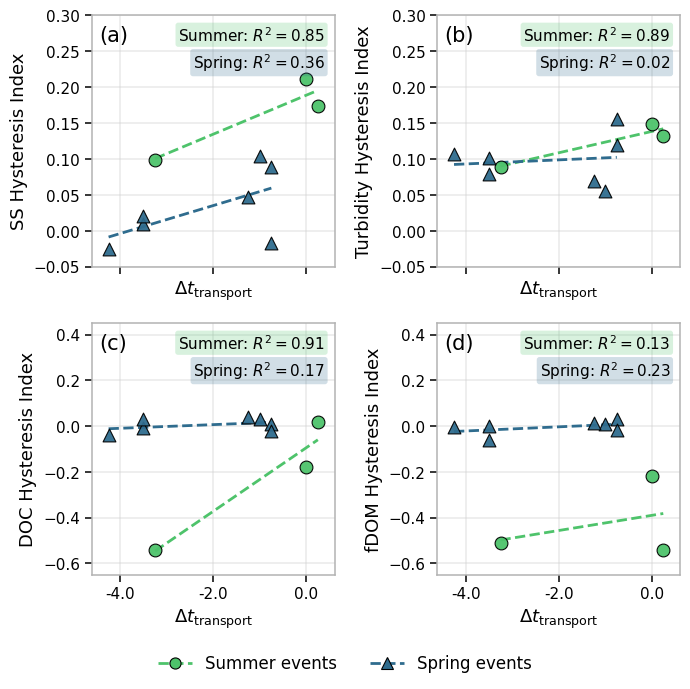

In [7]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(7, 7),
    sharex=True,
)

for ax, constituent in zip(axes.flat, constituents):

    r2_results = []

    for season in season_order:

        season_data = df[df["Season"] == season].copy()

        slope, intercept, r2, x_clean, y_clean = linear_regression(
            data=season_data,
            x_col="time",
            y_col=constituent,
        )

        # Plot observations
        ax.scatter(
            x_clean,
            y_clean,
            s=85,
            marker=season_markers[season],
            facecolor=season_colors[season],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
            label=season,
            zorder=3,
        )

        # Plot regression line
        if (
            len(x_clean) >= 2
            and np.unique(x_clean).size >= 2
            and np.isfinite(slope)
            and np.isfinite(intercept)
        ):
            x_line = np.linspace(
                np.min(x_clean),
                np.max(x_clean),
                200,
            )

            y_line = intercept + slope * x_line

            ax.plot(
                x_line,
                y_line,
                linestyle="--",
                linewidth=2,
                color=season_colors[season],
                zorder=2,
            )

        r2_results.append((season, r2))

    # --------------------------------------------------------
    # R² annotations
    # --------------------------------------------------------

    y_start = 0.96
    y_step = 0.105

    for i, (season, r2) in enumerate(r2_results):
        ax.text(
            0.96,
            y_start - i * y_step,
            rf"{season}: $R^2={format_r2(r2)}$",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            color="black",
            bbox=dict(
                facecolor=season_colors[season],
                edgecolor="none",
                boxstyle="round,pad=0.18",
                alpha=0.22,
            ),
            zorder=10,
        )

    # --------------------------------------------------------
    # Panel formatting
    # --------------------------------------------------------

    ax.set_xlabel(
        r"$\Delta t_{\mathrm{transport}}$",
        fontsize=13,
    )

    ax.set_ylabel(
        f"{constituent_labels[constituent]} Hysteresis Index",
        fontsize=13,
    )

    ax.xaxis.set_major_formatter(
        FormatStrFormatter("%.1f")
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=11,
        length=5,
        width=1.1,
    )

    ax.grid(
        True,
        color="lightgray",
        alpha=0.45,
        linewidth=1.2,
    )

    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_color("0.70")
        spine.set_linewidth(1.1)

    # Panel label
    ax.text(
        0.03,
        0.96,
        f"({panel_labels[constituent]})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=15,
    )


# ------------------------------------------------------------
# 5. Optional axis limits
# ------------------------------------------------------------

# SS and turbidity panels
axes[0, 0].set_ylim(-0.05, 0.30)
axes[0, 1].set_ylim(-0.05, 0.30)

# DOC and fDOM panels
axes[1, 0].set_ylim(-0.65, 0.45)
axes[1, 1].set_ylim(-0.65, 0.45)

# Set a common x-axis range with some padding
valid_time = df["time"].dropna()

if not valid_time.empty:
    x_min = valid_time.min()
    x_max = valid_time.max()
    x_padding = max((x_max - x_min) * 0.08, 0.2)

    for ax in axes.flat:
        ax.set_xlim(
            x_min - x_padding,
            x_max + x_padding,
        )


# ------------------------------------------------------------
# 6. Shared legend
# ------------------------------------------------------------

legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=season_markers[season],
        linestyle="--",
        linewidth=2,
        markersize=8,
        markerfacecolor=season_colors[season],
        markeredgecolor="black",
        markeredgewidth=0.8,
        color=season_colors[season],
        label=f"{season} events",
    )
    for season in season_order
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01),
    fontsize=12,
)


# ------------------------------------------------------------
# 7. Final layout and save
# ------------------------------------------------------------

fig.tight_layout(
    rect=[0, 0.07, 1, 1],
    h_pad=1.5,
    w_pad=1.5,
)

plt.savefig(
    "delta_transport_seasonal_regressions.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()